## Day 10: Monte Carlo Option Pricing & Greeks Explorer

In [86]:
# Setting up Parameters:
S0 = 150    # Spot
K = 155     # Strike
T = 1       # 1 year
r = 0.04    # Risk-free
sigma = 0.2 # Volatility
N = 100000  # MC paths


In [87]:
import numpy as np

Z = np.random.randn(N)
ST = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)

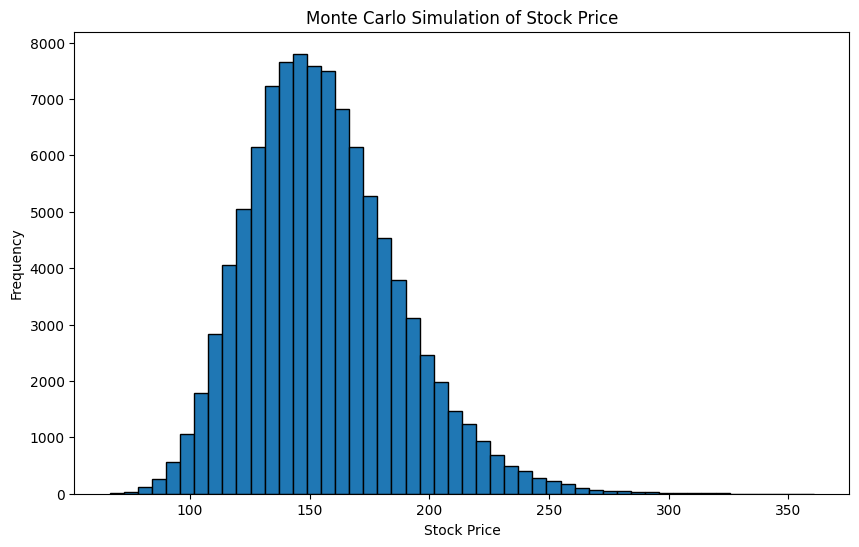

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(ST, bins=50, edgecolor='black')
plt.title('Monte Carlo Simulation of Stock Price')
plt.xlabel('Stock Price')
plt.ylabel('Frequency')

plt.show()

In [89]:
payoffs = np.maximum(ST-K,0)

# Then we have to discount the payoffs at the risk-free rate
discounted_payoffs = np.exp(-r*T)*payoffs

# The call option price is the average of the discounted payoffs
call_price = np.mean(discounted_payoffs)

print(f"Call Option Price: {call_price:.2f}")

Call Option Price: 12.37


In [90]:
# Now we want to compare this with the Black-Scholes formula

from scipy.stats import norm

d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
d2 = d1 - sigma*np.sqrt(T)

# there are no dividends being paid out, so we don't need to multiply by e^(-qT)
C_BS = S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2) 
print("Black-Scholes price:", C_BS)


Black-Scholes price: 12.451959613896776


Monte Carlo (12.56) is very close to Black–Scholes (12.45) which validates our MC implementation.

Small difference = stochastic noise from finite number of paths (can be reduced by more paths or variance reduction).

In [91]:
h = 0.1
ST_plus = (S0+h) * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
V_plus = np.mean(np.exp(-r*T) * np.maximum(ST_plus - K, 0))

ST_minus = (S0-h) * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
V_minus = np.mean(np.exp(-r*T) * np.maximum(ST_minus - K, 0))

Delta = (V_plus - V_minus) / (2*h)
Gamma = (V_plus - 2*call_price + V_minus) / (h**2)
print("Delta:", Delta, "Gamma:", Gamma)

Delta: 0.553715783669233 Gamma: 0.014943705991399266


##### Delta: For a $1 increase in spot, option value increases by ~$0.56, The option is slightly OTM → Delta < 0.5 is reasonable.
##### Gamma: Delta will increase by ~0.013 for a $1 move in the underlying. Small Gamma → convexity is moderate, as expected for a slightly OTM option with 1 year to expiry.

Delta tells you hedging ratio → need ~0.56 shares to hedge 1 call.

Gamma tells you how fast Delta changes → risk management for non-linear exposure.

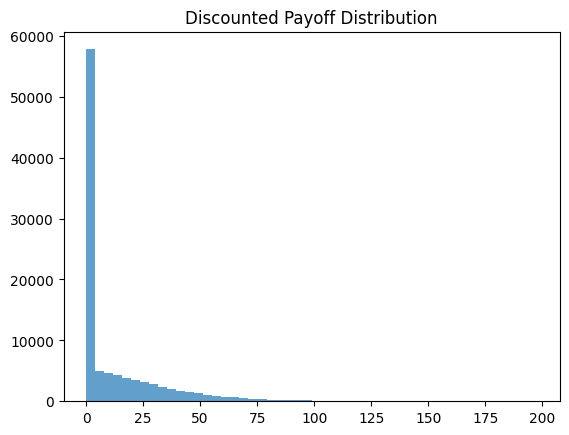

In [92]:
plt.hist(discounted_payoffs, bins=50, alpha=0.7)
plt.title("Discounted Payoff Distribution")
plt.show()


#### Since this was simulated on fake stock prices, lets use Real Market Data to simulate this!


In [93]:
import yfinance as yf
import pandas as pd

ticker = yf.Ticker('^SPX') # Using this as BS is primarily used for European options, not American options, which can be exercised at any time.

In [94]:
expirations = ticker.options
expirations

('2025-09-11',
 '2025-09-12',
 '2025-09-15',
 '2025-09-16',
 '2025-09-17',
 '2025-09-18',
 '2025-09-19',
 '2025-09-22',
 '2025-09-23',
 '2025-09-24',
 '2025-09-25',
 '2025-09-26',
 '2025-09-29',
 '2025-09-30',
 '2025-10-01',
 '2025-10-02',
 '2025-10-03',
 '2025-10-06',
 '2025-10-07',
 '2025-10-08',
 '2025-10-09',
 '2025-10-10',
 '2025-10-13',
 '2025-10-14',
 '2025-10-17',
 '2025-10-24',
 '2025-10-31',
 '2025-11-21',
 '2025-11-28',
 '2025-12-19',
 '2025-12-31',
 '2026-01-16',
 '2026-01-30',
 '2026-02-20',
 '2026-02-27',
 '2026-03-20',
 '2026-03-31',
 '2026-04-17',
 '2026-05-15',
 '2026-06-18',
 '2026-06-30',
 '2026-07-17',
 '2026-08-21',
 '2026-09-18',
 '2026-12-18',
 '2027-06-17',
 '2027-12-17',
 '2028-12-15',
 '2029-12-21',
 '2030-12-20')

In [95]:
options = ticker.option_chain('2025-09-18')

calls = options.calls
puts = options.puts

In [96]:
S0 = ticker.history(period='1d')['Close'][-1]

S0

C:\Users\Samneh\AppData\Local\Temp\ipykernel_9648\1505516287.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  S0 = ticker.history(period='1d')['Close'][-1]


6532.0400390625

In [97]:
def filter_calls(calls):
    calls_real = calls[
        (calls['strike'] > S0*0.5) &
        (calls['strike'] < S0*1.5) &
        (calls['volume'] > 0) &
        (calls['impliedVolatility'] > 0.001) &
        (calls['inTheMoney'] == False) 
    ]
    return calls_real

calls_real = filter_calls(calls)
calls_real

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
69,SPXW250918C06535000,2025-09-10 19:58:18+00:00,6535.0,46.00,50.40,50.70,0.000000,0.000000,57.0,0,0.135171,False,REGULAR,USD
70,SPXW250918C06540000,2025-09-11 07:53:13+00:00,6540.0,46.89,47.30,47.60,4.880001,11.616285,27.0,0,0.133348,False,REGULAR,USD
71,SPXW250918C06545000,2025-09-11 08:16:10+00:00,6545.0,45.15,44.30,44.60,4.950001,12.313434,1.0,0,0.131578,False,REGULAR,USD
72,SPXW250918C06550000,2025-09-10 19:55:57+00:00,6550.0,37.50,41.40,41.80,0.000000,0.000000,171.0,0,0.130109,False,REGULAR,USD
73,SPXW250918C06555000,2025-09-10 19:59:05+00:00,6555.0,34.90,38.50,38.90,0.000000,0.000000,87.0,0,0.128160,False,REGULAR,USD
74,SPXW250918C06560000,2025-09-10 19:24:26+00:00,6560.0,26.01,35.90,36.20,0.000000,0.000000,77.0,0,0.126504,False,REGULAR,USD
75,SPXW250918C06565000,2025-09-10 15:58:14+00:00,6565.0,33.53,33.30,33.60,0.000000,0.000000,21.0,0,0.124871,False,REGULAR,USD
76,SPXW250918C06570000,2025-09-10 20:09:38+00:00,6570.0,26.61,30.80,31.10,0.000000,0.000000,84.0,0,0.123262,False,REGULAR,USD
77,SPXW250918C06575000,2025-09-10 19:50:02+00:00,6575.0,23.82,28.40,28.70,0.000000,0.000000,32.0,0,0.121659,False,REGULAR,USD
78,SPXW250918C06580000,2025-09-10 19:57:04+00:00,6580.0,23.90,26.10,26.40,0.000000,0.000000,32.0,0,0.120073,False,REGULAR,USD


Text(0, 0.5, 'Frequency')

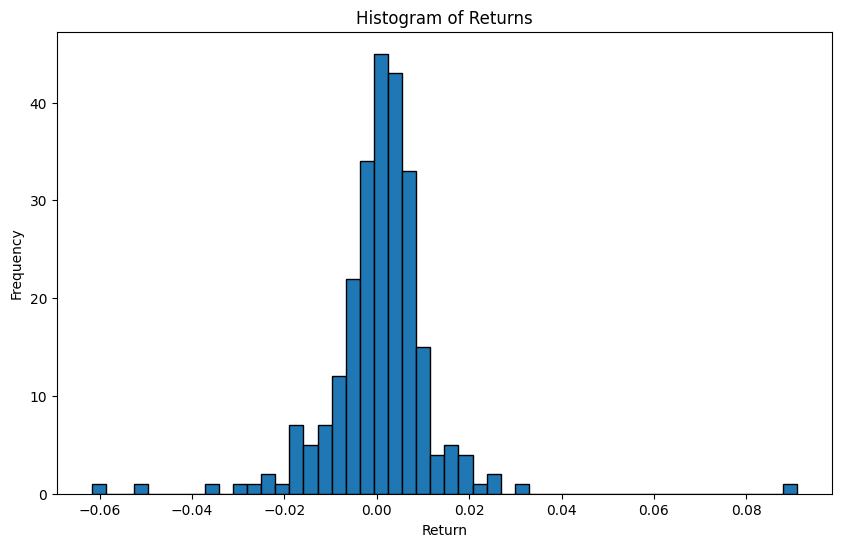

In [98]:
hist = ticker.history(period='1y')
returns = (np.log(hist['Close'] / hist['Close'].shift(1))).dropna()

plt.figure(figsize=(10, 6))
plt.hist(returns, bins=50, edgecolor='black')
plt.title('Histogram of Returns')
plt.xlabel('Return')
plt.ylabel('Frequency')

In [99]:
hist_vol = returns.std()
hist_vol_annualized = hist_vol * np.sqrt(252) # Annualized Volatility


print(f"Historical Volatility: {hist_vol:.3f}")
print(f"Annualized Historical Volatility: {hist_vol_annalized:.3f}")

Historical Volatility: 0.012
Annualized Historical Volatility: 0.187


In [100]:
r = 0.0433 # Risk-free rate
S0 = S0
h= 0.1
T = 7/365
sigma = hist_vol_annualized
K = 6560


N = 100000
Z = np.random.randn(N)

In [ ]:
from scipy.stats import norm

def black_scholes_mc(S0, K, h, T, sigma, r, Z):
    # --------------------
    # BLACK–SCHOLES (Closed-Form)
    # --------------------
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    
    # Closed-form BS price (European call, no dividends)
    C_BS = S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

    # --------------------
    # MONTE CARLO (Simulation)
    # --------------------
    # Baseline Monte Carlo option price
    ST = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
    V0 = np.mean(np.exp(-r*T) * np.maximum(ST - K, 0))

    # Monte Carlo bumped prices
    ST_plus = (S0+h) * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
    V_plus = np.mean(np.exp(-r*T) * np.maximum(ST_plus - K, 0))

    ST_minus = (S0-h) * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
    V_minus = np.mean(np.exp(-r*T) * np.maximum(ST_minus - K, 0))

    # Greeks via finite differences
    Delta = (V_plus - V_minus) / (2*h)
    Gamma = (V_plus - 2*V0 + V_minus) / (h**2)

    return C_BS, V0, V_plus, V_minus, Delta, Gamma

In [102]:
C_BS, ST_plus, ST_minus, V_plus, V_minus, Delta, Gamma = black_scholes(S0,K, h, T, sigma, Z)

print("The Black Scholes Price: ", C_BS)
print("The Monte Carlo Higher value: ", ST_plus)
print("The Monte Carlo Lower value: ", ST_minus)
print("The V Plus, i dont knwo what this is: " , V_plus)
print("The V minus, i dont knwo what this is: " , V_minus)
print("The Delta, ", Delta)
print("The Gamma ", Gamma)

The Black Scholes Price:  56.98940608537259
The Monte Carlo Higher value:  [6496.41560904 6331.58413786 6526.48753616 ... 6454.84454257 6330.88286116
 6462.34778233]
The Monte Carlo Lower value:  [6496.21670284 6331.39027845 6526.28770923 ... 6454.6469092  6330.68902321
 6462.14991922]
The V Plus, i dont knwo what this is:  57.40557775230625
The V minus, i dont knwo what this is:  57.314992950192995
The Delta,  0.45292401056627796
The Gamma  -1294935.9507422498
